# Model 2 of 5 — Cell Detection: YOLOv11 on BCCD
**Hematological AI Decision Support System — MSc Biotechnology, VIT**

**Goal:** Draw bounding boxes around every RBC, WBC, and Platelet in a raw blood smear image.

**Dataset:** BCCD (Blood Cell Count Detection) — small, free, already YOLO-annotated.

**Pipeline stage:** Model 2 of 5. This detector's outputs (crops) are what Model 3 (segmentation) and Model 1's classifier operate on downstream in the full demo pipeline — so keep the exported weights.

Run in Colab with a **GPU runtime** (Runtime → Change runtime type → T4 GPU).

In [1]:
# 1. Environment setup
!pip install -q ultralytics

from ultralytics import YOLO
import torch, os, yaml, shutil
from pathlib import Path

device = 0 if torch.cuda.is_available() else 'cpu'
print("Device:", device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 2.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: 0


## 2. Dataset — BCCD (via HuggingFace `datasets`, no API key needed)

We use `keremberke/blood-cell-object-detection` on HuggingFace — this is the same BCCD dataset your roadmap names, already split into train/valid/test with bounding-box annotations. No login, no API key, no flaky zip URLs — just `pip install datasets`.

We convert its annotations into standard YOLO `.txt` format + `data.yaml` so the rest of the notebook (Ultralytics training) works unchanged.

In [5]:
# 3. Download BCCD via HuggingFace datasets (parquet mirror — no API key, no loading script)
!pip install -q datasets pillow

from datasets import load_dataset

hf_ds = load_dataset(
    "keremberke/blood-cell-object-detection",
    name="default",
    revision="refs/convert/parquet",
)
print(hf_ds)

# Inspect structure first (parquet mirrors sometimes nest 'objects' differently than the original script)
print("\nFeatures:", hf_ds['train'].features)
print("\nSample row 'objects':", hf_ds['train'][0]['objects'])

# Extract class names robustly
obj_feat = hf_ds['train'].features['objects']
if hasattr(obj_feat, 'feature'):
    CLASS_NAMES = obj_feat.feature['category'].names
else:
    # dict-of-lists layout: category names live one level down
    CLASS_NAMES = obj_feat['category'].feature.names

print("\nCategory names:", CLASS_NAMES)

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 258
    })
    validation: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 76
    })
    test: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 39
    })
})

Features: {'image_id': Value('int64'), 'image': Image(mode=None, decode=True), 'width': Value('int32'), 'height': Value('int32'), 'objects': {'id': List(Value('int64')), 'area': List(Value('int64')), 'bbox': List(List(Value('float32'), length=4)), 'category': List(ClassLabel(names=['platelets', 'rbc', 'wbc']))}}

Sample row 'objects': {'id': [1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995], 'area': [4588, 7735, 6498, 4693, 9082, 3444, 8917, 3111, 955], 'bbox': [[1.0, 142.0, 57.0, 80.5], [30.0, 58.0, 81.0, 95.5], [188.0, 76.0, 69.5, 93.5], [232.0, 160.0, 63.0, 74.5], [63.0, 278.0, 86.5, 105.0], [9.0, 281.

In [7]:
# 4. Convert HF dataset -> YOLO format (images/ + labels/ + data.yaml)
import shutil
from pathlib import Path
from PIL import Image
import yaml

ROOT = Path('bccd_yolo')
if ROOT.exists():
    shutil.rmtree(ROOT)

# Robust class name extraction (works regardless of parquet-mirror nesting)
obj_feat = hf_ds['train'].features['objects']
if hasattr(obj_feat, 'feature'):
    CLASS_NAMES = obj_feat.feature['category'].names
else:
    CLASS_NAMES = obj_feat['category'].feature.names
print("Classes:", CLASS_NAMES)

# Peek at one example to confirm the objects layout, then branch conversion logic
sample_objs = hf_ds['train'][0]['objects']
print("Sample objects layout:", sample_objs)

def extract_cat_bbox_pairs(objs):
    """Return list of (category:int, bbox:[x,y,w,h]) regardless of nesting style."""
    if isinstance(objs, dict):
        # dict-of-lists: {'category': [...], 'bbox': [...]}
        return list(zip(objs['category'], objs['bbox']))
    elif isinstance(objs, list):
        # list-of-dicts: [{'category':..., 'bbox':...}, ...]
        return [(o['category'], o['bbox']) for o in objs]
    else:
        raise ValueError(f"Unrecognized objects layout: {type(objs)}")

split_map = {'train': 'train', 'validation': 'valid', 'test': 'test'}

for hf_split, out_split in split_map.items():
    if hf_split not in hf_ds:
        continue
    img_dir = ROOT / out_split / 'images'
    lbl_dir = ROOT / out_split / 'labels'
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    for idx, example in enumerate(hf_ds[hf_split]):
        img = example['image'].convert('RGB')
        w, h = img.size
        fname = f"{out_split}_{idx:05d}"
        img.save(img_dir / f"{fname}.jpg")

        pairs = extract_cat_bbox_pairs(example['objects'])
        lines = []
        for cat, bbox in pairs:
            x_min, y_min, bw, bh = bbox
            xc = (x_min + bw / 2) / w
            yc = (y_min + bh / 2) / h
            nw = bw / w
            nh = bh / h
            lines.append(f"{cat} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")

        with open(lbl_dir / f"{fname}.txt", 'w') as f:
            f.write("\n".join(lines))

    n_imgs = len(list(img_dir.glob('*.jpg')))
    print(f"{out_split}: {n_imgs} images written to {img_dir}")

# Build data.yaml for Ultralytics
data_yaml_content = {
    'path': str(ROOT.resolve()),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': len(CLASS_NAMES),
    'names': CLASS_NAMES,
}
DATA_YAML = str(ROOT / 'data.yaml')
with open(DATA_YAML, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False)

print("\ndata.yaml written to:", DATA_YAML)
print(yaml.dump(data_yaml_content))

Classes: ['platelets', 'rbc', 'wbc']
Sample objects layout: {'id': [1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995], 'area': [4588, 7735, 6498, 4693, 9082, 3444, 8917, 3111, 955], 'bbox': [[1.0, 142.0, 57.0, 80.5], [30.0, 58.0, 81.0, 95.5], [188.0, 76.0, 69.5, 93.5], [232.0, 160.0, 63.0, 74.5], [63.0, 278.0, 86.5, 105.0], [9.0, 281.0, 56.0, 61.5], [142.0, 157.0, 74.0, 120.5], [69.0, 204.0, 49.0, 63.5], [33.0, 30.0, 24.5, 39.0]], 'category': [1, 1, 1, 1, 1, 1, 2, 0, 0]}
train: 258 images written to bccd_yolo/train/images
valid: 76 images written to bccd_yolo/valid/images
test: 39 images written to bccd_yolo/test/images

data.yaml written to: bccd_yolo/data.yaml
names:
- platelets
- rbc
- wbc
nc: 3
path: /content/bccd_yolo
test: test/images
train: train/images
val: valid/images



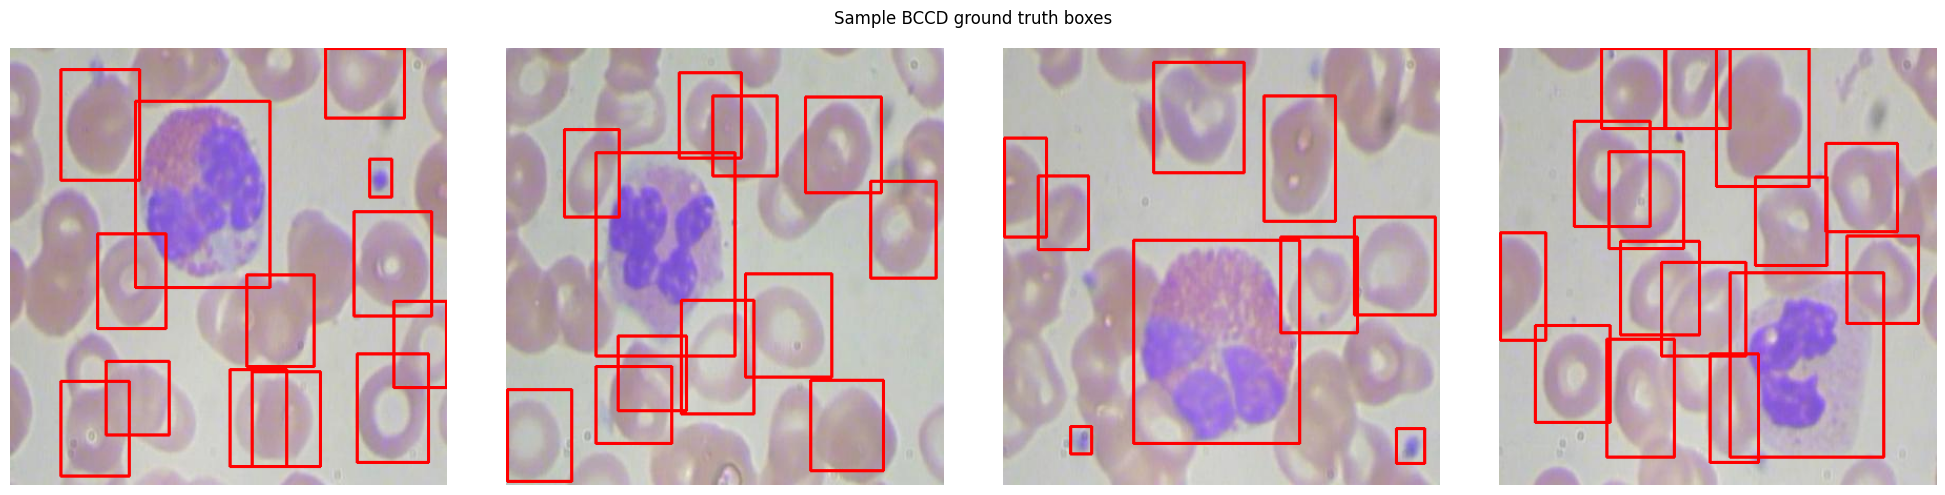

In [8]:
# 5. Sanity check — visualize a few labeled samples
import cv2
import matplotlib.pyplot as plt

img_dir = Path(DATA_YAML).parent / 'train' / 'images'
lbl_dir = Path(DATA_YAML).parent / 'train' / 'labels'
sample_imgs = list(img_dir.glob('*'))[:4]

fig, axes = plt.subplots(1, 4, figsize=(20,5))
for ax, img_path in zip(axes, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = lbl_dir / (img_path.stem + '.txt')
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())
                x1, y1 = int((xc-bw/2)*w), int((yc-bh/2)*h)
                x2, y2 = int((xc+bw/2)*w), int((yc+bh/2)*h)
                cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
    ax.imshow(img); ax.axis('off')
plt.suptitle('Sample BCCD ground truth boxes')
plt.tight_layout()
plt.show()

## 6. Train YOLOv11 (transfer learning from pretrained COCO weights)

We fine-tune `yolo11s.pt` (small variant — best accuracy/speed trade-off for a Colab GPU and a dataset this size). This is transfer learning, not training from scratch — matches your roadmap's "Low–Medium" effort rating.

In [9]:
# 6. Train
model = YOLO('yolo11s.pt')  # pretrained on COCO, auto-downloads

results = model.train(
    data=DATA_YAML,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=15,          # early stopping
    device=device,
    project='bccd_runs',
    name='yolov11_bccd',
    augment=True,         # built-in mosaic/hsv/flip augmentation
    seed=42,
    val=True,
    plots=True,
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=bccd_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov11_bccd, nbs=64, nms=False, opset=No

## 7. Validation — mAP, precision, recall

Per your roadmap Build Step 4: "Validate with mAP, precision, and recall".

In [10]:
# 7. Validate on the held-out test split
metrics = model.val(data=DATA_YAML, split='test')

print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

# Per-class breakdown (RBC / WBC / Platelet)
class_names = model.names
for i, name in class_names.items():
    print(f"  {name}: AP50={metrics.box.ap50[i]:.4f}  AP50-95={metrics.box.ap[i]:.4f}")

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 16.3±13.4 MB/s, size: 12.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/bccd_yolo/test/labels... 39 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 39/39 1.2Kit/s 0.0s
val: New cache created: /content/bccd_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.5s
                   all         39        514       0.81      0.899      0.909      0.612
             platelets         21         37       0.76      0.858      0.868      0.439
                   rbc         37        438      0.781      0.865      0.893      0.636
                   

In [11]:
# 7b. Plot training curves (loss, mAP over epochs) — auto-saved by Ultralytics
import matplotlib.image as mpimg

results_png = Path('bccd_runs/yolov11_bccd/results.png')
if results_png.exists():
    img = mpimg.imread(results_png)
    plt.figure(figsize=(16,10))
    plt.imshow(img); plt.axis('off')
    plt.show()

confusion_png = Path('bccd_runs/yolov11_bccd/confusion_matrix.png')
if confusion_png.exists():
    img = mpimg.imread(confusion_png)
    plt.figure(figsize=(8,8))
    plt.imshow(img); plt.axis('off')
    plt.title('Confusion Matrix')
    plt.show()

## 8. Inference on sample smear images — inspect boxes

Per Build Step 5. Run the fine-tuned detector on held-out test images and visually confirm boxes look right before moving on.

Using weights: /content/runs/detect/bccd_runs/yolov11_bccd/weights/best.pt


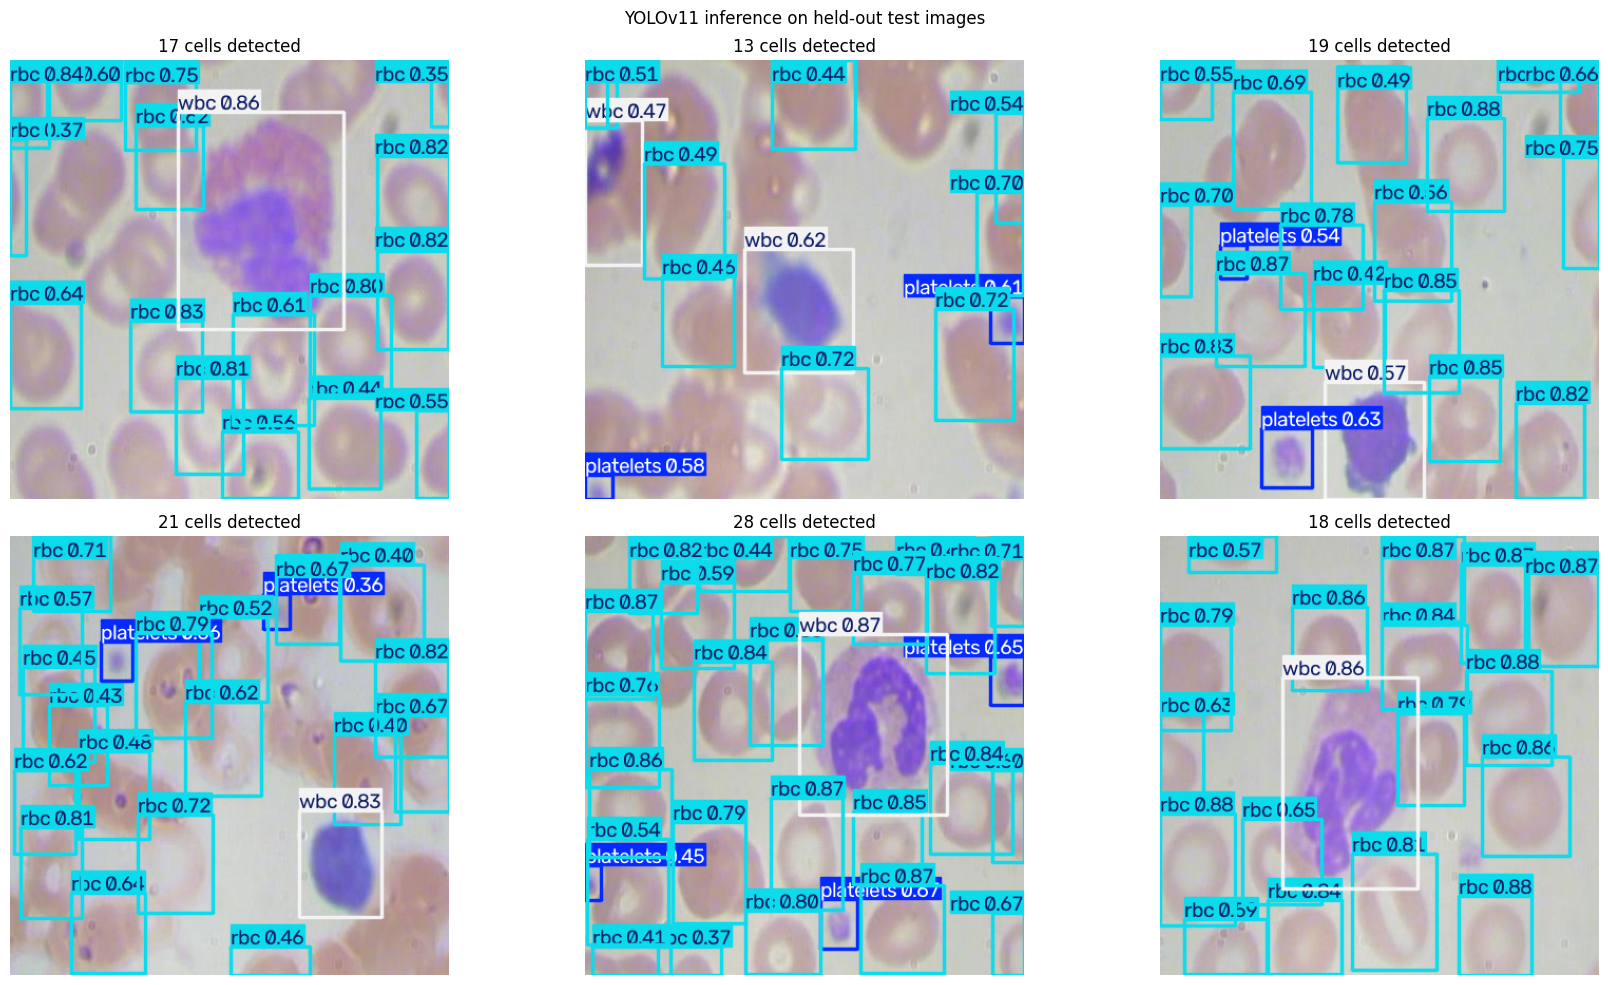

In [15]:
# 8. Run inference + visualize
import glob

search_roots = ['bccd_runs', '/content/runs/detect/bccd_runs', 'runs/detect/bccd_runs']
weight_candidates = []
for root in search_roots:
    weight_candidates += glob.glob(f'{root}/**/weights/best.pt', recursive=True)

if not weight_candidates:
    raise FileNotFoundError("No best.pt found — check training cell output for the actual save_dir path.")

best_weights = max(weight_candidates, key=lambda p: Path(p).stat().st_mtime)
print("Using weights:", best_weights)

inference_model = YOLO(best_weights)

test_img_dir = Path(DATA_YAML).parent / 'test' / 'images'
test_samples = list(test_img_dir.glob('*'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18,10))
for ax, img_path in zip(axes.flatten(), test_samples):
    result = inference_model.predict(str(img_path), conf=0.35, verbose=False)[0]
    annotated = result.plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated); ax.axis('off')
    ax.set_title(f"{len(result.boxes)} cells detected")
plt.suptitle('YOLOv11 inference on held-out test images')
plt.tight_layout()
plt.savefig('yolo_inference_samples.png', dpi=150)
plt.show()

## 9. Cell counting from detections

This directly feeds **Block 8** of your pipeline poster (Cell Counting: RBC/WBC/Platelet totals + differential WBC %), and the counts here become one of the three feature groups Model 5 (risk prediction) consumes later.

In [16]:
# 9. Aggregate counts per image (this logic reuses downstream in the full demo app)
def count_cells(image_path, model, conf=0.35):
    result = model.predict(str(image_path), conf=conf, verbose=False)[0]
    counts = {name: 0 for name in class_names.values()}
    for cls_id in result.boxes.cls.cpu().numpy():
        counts[class_names[int(cls_id)]] += 1
    return counts

for img_path in test_samples[:3]:
    counts = count_cells(img_path, inference_model)
    print(f"{img_path.name}: {counts}")

test_00005.jpg: {'platelets': 0, 'rbc': 16, 'wbc': 1}
test_00003.jpg: {'platelets': 2, 'rbc': 9, 'wbc': 2}
test_00001.jpg: {'platelets': 2, 'rbc': 16, 'wbc': 1}


## 10. Save + export weights for reuse in later models

Per Build Step 6: "Export the trained weights for reuse in later models." This checkpoint is what feeds cropped cell regions into **Model 3 (Segmentation)** in the full pipeline demo.

In [17]:
# 10. Export
import shutil, json

# Copy best weights to a clean, memorable name
shutil.copy(best_weights, 'yolov11_bccd_best.pt')

# Export to ONNX too — useful for the Deployment block (edge device / web app) in your poster
inference_model.export(format='onnx')

detection_summary = {
    'model': 'YOLOv11s',
    'dataset': 'BCCD',
    'classes': list(class_names.values()),
    'mAP50': float(metrics.box.map50),
    'mAP50_95': float(metrics.box.map),
    'precision': float(metrics.box.mp),
    'recall': float(metrics.box.mr),
}
with open('model2_results_summary.json', 'w') as f:
    json.dump(detection_summary, f, indent=2)

print(json.dumps(detection_summary, indent=2))

# Recommended: save to Drive
# from google.colab import drive
# drive.mount('/content/drive')
# for fname in ['yolov11_bccd_best.pt', 'model2_results_summary.json', 'yolo_inference_samples.png']:
#     shutil.copy(fname, f'/content/drive/MyDrive/hematology_project/model2_detection/{fname}')

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/bccd_runs/yolov11_bccd/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (18.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 293ms
Prepared 4 packages in 1.83s
Installed 4 packages in 377ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.28.0
 + onnxslim==0.1.95

requirements: AutoUpdate success ✅ 3.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.95...
ONNX: export success ✅ 5.9s, saved as '/co

In [18]:
# 10b. Package + download all Model 2 outputs to your local machine
import shutil
from pathlib import Path
from google.colab import files

weights_dir = Path('/content/runs/detect/bccd_runs/yolov11_bccd/weights')

DOWNLOAD_DIR = Path('/content/model2_download')
DOWNLOAD_DIR.mkdir(exist_ok=True)

# Copy the key artifacts
for fname in ['best.pt', 'best.onnx']:
    src = weights_dir / fname
    if src.exists():
        shutil.copy(src, DOWNLOAD_DIR / fname)

for fname in ['model2_results_summary.json', 'yolo_inference_samples.png']:
    if Path(fname).exists():
        shutil.copy(fname, DOWNLOAD_DIR / fname)

# Also grab training curves + confusion matrix from the run folder
run_dir = Path('/content/runs/detect/bccd_runs/yolov11_bccd')
for fname in ['results.png', 'confusion_matrix.png', 'results.csv']:
    src = run_dir / fname
    if src.exists():
        shutil.copy(src, DOWNLOAD_DIR / fname)

print("Packaged files:")
for f in DOWNLOAD_DIR.iterdir():
    print(f" -", f.name, f"({f.stat().st_size / 1e6:.1f} MB)")

# Zip and download
zip_path = shutil.make_archive('/content/model2_cell_detection', 'zip', DOWNLOAD_DIR)
print(f"\nZipped to: {zip_path}")
files.download(zip_path)

Packaged files:
 - model2_results_summary.json (0.0 MB)
 - results.png (0.2 MB)
 - results.csv (0.0 MB)
 - best.onnx (37.9 MB)
 - yolo_inference_samples.png (2.3 MB)
 - confusion_matrix.png (0.1 MB)
 - best.pt (19.2 MB)

Zipped to: /content/model2_cell_detection.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Next: Model 3 of 5 — Cell Segmentation (U-Net on SegPC-2021 / Raabin-WBC)

Say **"build model 3"** and I'll produce that notebook next — U-Net with Dice+BCE loss, IoU/Dice evaluation, mask overlays, and morphological feature extraction (area, circularity, N/C ratio) that Model 5 needs later.

**Notes for your write-up:**
- State the exact BCCD version/source URL and download date in your Methods — Roboflow dataset versions get updated, so reproducibility requires pinning it.
- mAP50-95 is the stricter, IoU-averaged metric — report both mAP50 and mAP50-95, reviewers expect it.
- If platelet AP is noticeably lower than RBC/WBC (common — platelets are small and easy to miss), flag it explicitly; that's a legitimate finding to discuss, not a bug to hide.
